In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cftime

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import nc_time_axis 
from scipy.stats import linregress


In [2]:
def selBoundary(data):
    return data.sel(lon=slice(360-90,360-65), lat=slice(25,50))

In [5]:
# HadGEM3-GC31-LL historical aerosols only, 1950-2020
vars = ['rlut', 'rsut'] # SW and LW outgoing
var_datasets = {}
for var in vars:
    data_dir = f'./CMIP6/DAMIP/MOHC/HadGEM3-GC31-LL/hist-aer/r1i1p1f3/Amon/{var}/gn/v20190814/'
    filename = f'{var}_Amon_HadGEM3-GC31-LL_hist-aer_r1i1p1f3_gn_195001-202012.nc'
    data = xr.open_dataset(f'{data_dir}{filename}')
    subset = selBoundary(data[var])
    var_datasets[var] = subset

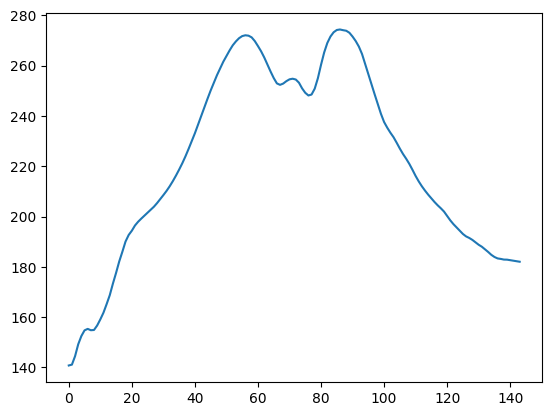

In [28]:
plt.plot(data['rlut'].mean(['lon', 'time']))

In [124]:
test_data = data['rlut'].sel(time=cftime.Datetime360Day(2020, 1, 16, 0, 0, 0, 0, has_year_zero=True))

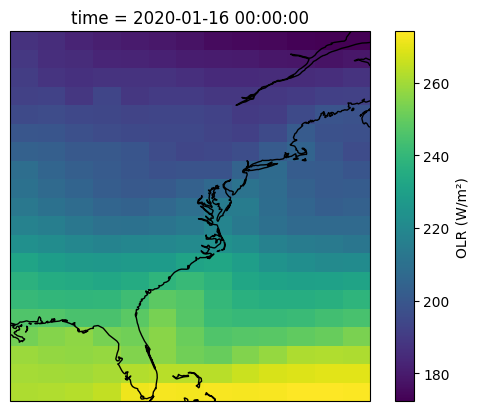

In [146]:
subset = var_datasets['rlut']
plot_subset = subset.sel(time=cftime.Datetime360Day(2020, 1, 16, 0, 0, 0, 0, has_year_zero=True))
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
plot_subset.plot.pcolormesh(
    ax=ax,
    x='lon', y='lat',
    transform=ccrs.PlateCarree(),   # tells cartopy the data's CRS (0-360 is fine here)
    cmap='viridis',
    cbar_kwargs={'label': 'OLR (W/m²)'},
)
ax.coastlines()


In [189]:
model = linregress(np.arange(annual_mean[20:].size), annual_mean[20:].data)

In [190]:
model.slope # W/m^2 per year

np.float64(-0.06260028200451605)

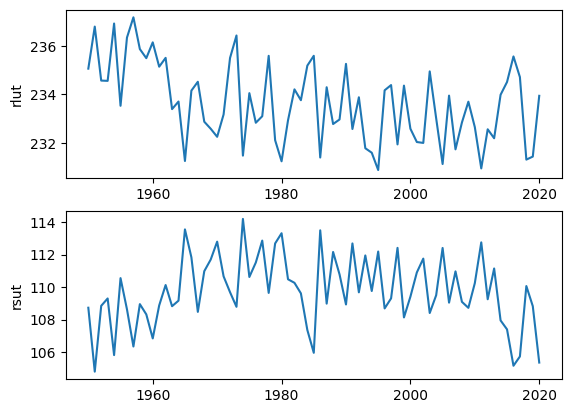

In [174]:
# compute means over the whole domain
fig, axs = plt.subplots(2,1)
for ax, var in zip(axs, vars):
    dataset = var_datasets[var]
    weights = np.cos(np.deg2rad(dataset.lat))

    weighted_subset = dataset.weighted(weights)
    weighted_mean = dataset.mean(('lat', 'lon'))
    annual_mean = weighted_mean.resample(time="YS").mean()

    ax.plot(annual_mean.time, annual_mean, )
    ax.set_ylabel(var)

Per grid cell slope in rlut/rsut since 1970?

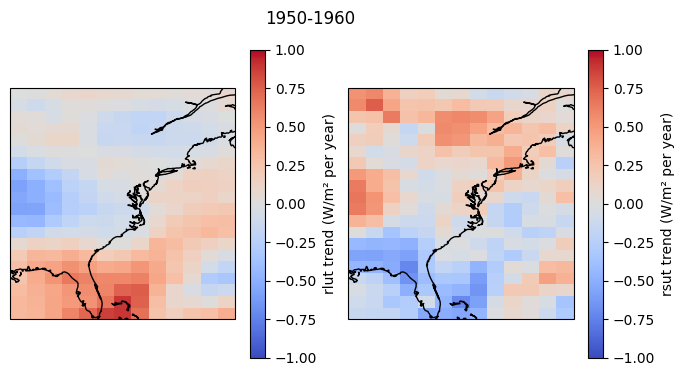

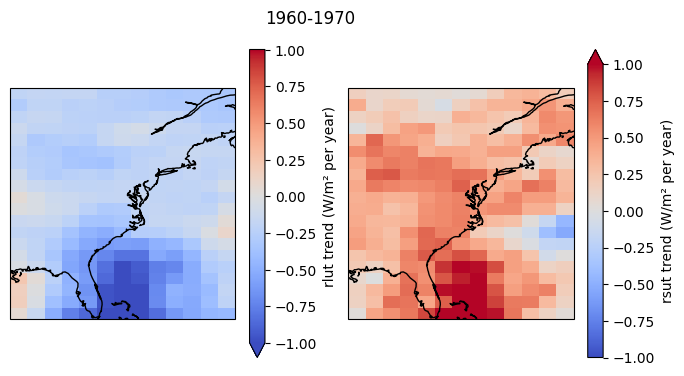

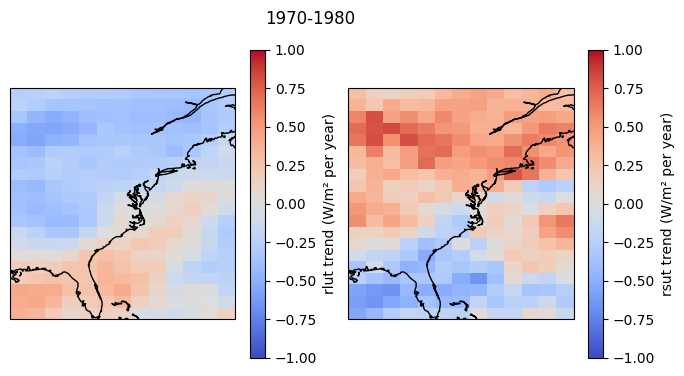

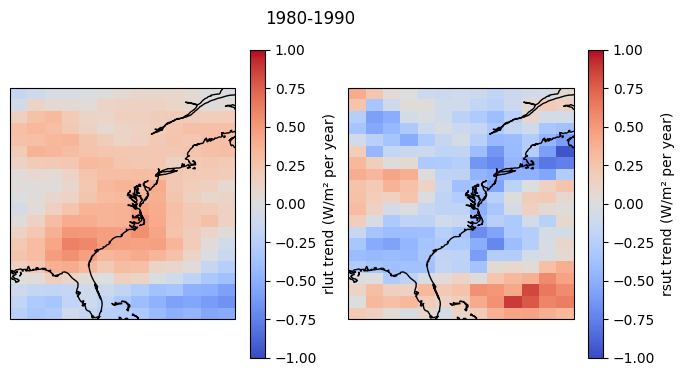

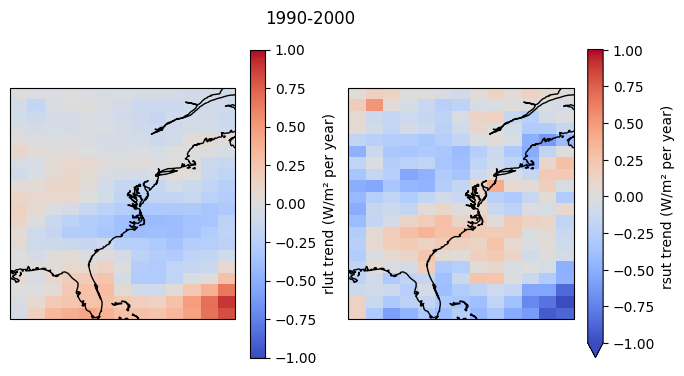

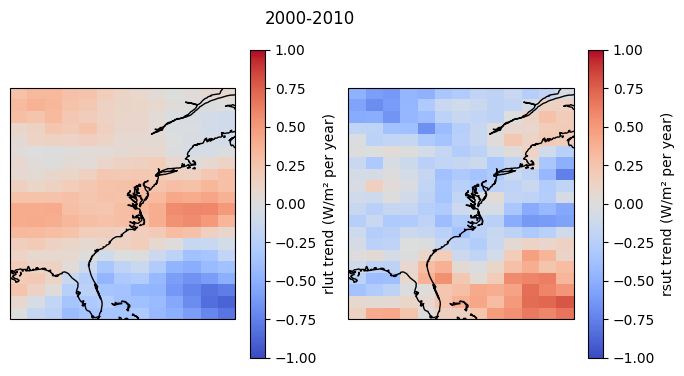

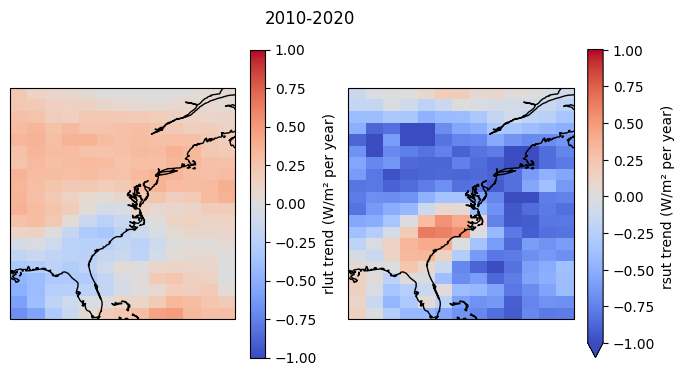

In [259]:
#fig, axs = plt.subplots(2,1)

for ystart, yend in zip(np.linspace(1950, 2010, 7, dtype=int), np.linspace(1960, 2020, 7, dtype=int)):
    fig, axs = plt.subplots(1, 2, figsize=(8, 4), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
    for ax, var in zip(axs, vars):
        dataset = var_datasets[var]
        dataset_annual = dataset.resample(time="YS").mean()
        #dataset_annual = dataset # for monthly

        slope_vals = np.zeros((20,13))

        istart, iend = ystart-1950, yend-1950
        #istart, iend = 12*istart, 12*iend # for monthly
        for i, lat in enumerate(dataset_annual.lat):
            for j, lon in enumerate(dataset_annual.lon):
                dataset_annual_latlon = dataset_annual.sel(lat=lat, lon=lon)
                # linear model, 1970 onward
                model = linregress(np.arange(dataset_annual_latlon[istart:iend+1].size), dataset_annual_latlon[istart:iend+1].data)
                slope = model.slope # W/m^2 per year
                slope_vals[i,j] = slope

        new_ds = dataset_annual.to_dataset().assign(trend=(('lat', 'lon'), slope_vals))

        plot_subset = new_ds['trend']

        
        plot_subset.plot.pcolormesh(
            ax=ax,
            x='lon', y='lat',
            transform=ccrs.PlateCarree(),   # tells cartopy the data's CRS (0-360 is fine here)
            cmap='coolwarm',
            cbar_kwargs={'label': f'{var} trend (W/m² per year)'},
            vmin=-1, vmax=1
        )
        ax.coastlines()
    plt.suptitle(f'{ystart}-{yend}')
    plt.savefig(f'lw-sw-trend-{ystart}-{yend}.pdf', format='pdf')

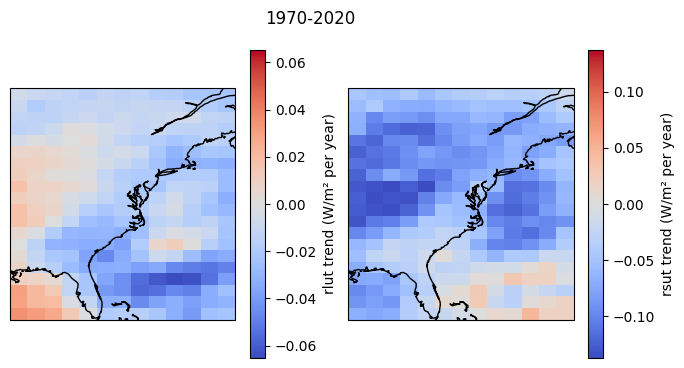

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
for ax, var in zip(axs, vars):
    dataset = var_datasets[var]
    dataset_annual = dataset.resample(time="YS").mean()
    #dataset_annual = dataset # for monthly

    slope_vals = np.zeros((20,13))

    ystart, yend = 1970, 2020
    istart, iend = ystart-1950, yend-1950
    #istart, iend = 12*istart, 12*iend # for monthly
    for i, lat in enumerate(dataset_annual.lat):
        for j, lon in enumerate(dataset_annual.lon):
            dataset_annual_latlon = dataset_annual.sel(lat=lat, lon=lon)
            # linear model, 1970 onward
            model = linregress(np.arange(dataset_annual_latlon[istart:iend+1].size), dataset_annual_latlon[istart:iend+1].data)
            slope = model.slope # W/m^2 per year
            slope_vals[i,j] = slope

    new_ds = dataset_annual.to_dataset().assign(trend=(('lat', 'lon'), slope_vals))

    plot_subset = new_ds['trend']

    
    plot_subset.plot.pcolormesh(
        ax=ax,
        x='lon', y='lat',
        transform=ccrs.PlateCarree(),   # tells cartopy the data's CRS (0-360 is fine here)
        cmap='coolwarm',
        cbar_kwargs={'label': f'{var} trend (W/m² per year)'},
        #vmin=-1, vmax=1
    )
    ax.coastlines()
plt.suptitle(f'{ystart}-{yend}')
plt.savefig(f'lw-sw-trend-{ystart}-{yend}.pdf', format='pdf')

In [129]:
# select data subset and find the mean value over lat/lon for the eastern US (need to weight latitudes by grid cell size)
data_subset = selBoundary(data)
weighted_subset = data_subset['rlut'].weighted(weights.sel(lat=slice(25,50)))
weighted_mean = weighted_subset.mean(('lat', 'lon'))

In [130]:
weighted_mean.resample(time="YS").mean()

<xarray.DataArray 'rlut' (time: 71)> Size: 568B
array([236.31590032, 238.24037668, 235.96955037, 235.90888342,
       238.37616126, 234.84307216, 237.82112567, 238.58893957,
       237.25019371, 236.98408674, 237.65030378, 236.69057562,
       236.99487926, 234.70386527, 234.96537605, 232.53280851,
       235.40544347, 235.8194147 , 234.25554271, 234.04966549,
       233.64908303, 234.51290582, 237.01515934, 237.92595103,
       233.04837595, 235.37341001, 234.41538952, 234.4647145 ,
       237.23428772, 233.6550415 , 232.84561876, 234.30199639,
       235.82527757, 235.18013072, 236.55645528, 236.83488018,
       232.76182571, 235.58815384, 234.28936705, 234.46058495,
       236.69012178, 233.98033414, 235.48346729, 233.36488735,
       233.05848372, 232.27227026, 235.44412588, 235.73584214,
       233.40259231, 236.04477856, 234.12674754, 233.4335435 ,
       233.57919105, 236.46754033, 234.62753329, 232.66728084,
       235.30526189, 233.23969657, 234.02839456, 235.15583883,
       234.14218158, 232.36192683, 234.06340484, 233.6978179 ,
       235.3762736 , 235.94075233, 237.16428442, 236.26038138,
       232.67324104, 232.75623893, 235.3245452 ])
Coordinates:
  * time     (time) object 568B 1950-01-01 00:00:00 ... 2020-01-01 00:00:00
Attributes:
    standard_name:  toa_outgoing_longwave_flux
    long_name:      TOA Outgoing Longwave Radiation
    comment:        at the top of the atmosphere (to be compared with satelli...
    units:          W m-2
    original_name:  mo: (stash: m01s03i332, lbproc: 128)
    cell_methods:   area: time: mean
    cell_measures:  area: areacella
    history:        2019-08-09T16:24:13Z altered by CMOR: replaced missing va...

In [133]:
annual_avg = weighted_mean.resample(time="YS").mean()

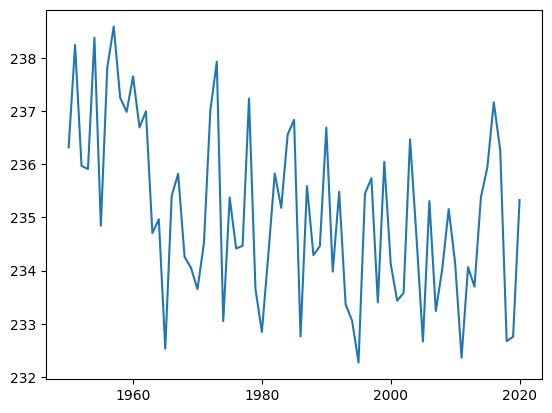

In [134]:
plt.plot(annual_avg.time, annual_avg)


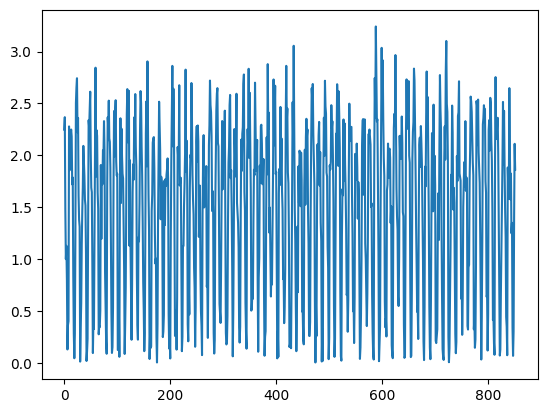

In [135]:
# error if you dont account for the latitude weighting
plt.plot(abs(weighted_mean - data_subset.rlut.mean(('lat', 'lon'))))

In [3]:
from intake_esgf import ESGFCatalog
import os, glob
from functools import partial
import pandas as pd

In [4]:
def _selBoundary(data):
    return data.sel(time=slice('1850-01-01', '2020-12-01'), lon=slice(360-90,360-65), lat=slice(25,50))
    
def importModelData(model_info):
    m = model_info
    data_dir = f'./{m.project}/{m.activity_drs}/{m.institution_id}/{m.source_id}/{m.experiment_id}/{m.member_id}/{m.table_id}/{m.variable_id}/{m.grid_label}/v{m.version}/'
    #print(data_dir)
    full_data_path = os.path.normpath(os.path.join(os.getcwd(), data_dir))

    data_files = sorted(glob.glob(f'{full_data_path}/*.nc'))
    #print(data_files)
    partial_func = partial(_selBoundary)
    ds = xr.open_mfdataset(data_files, concat_dim='time', combine='nested', preprocess=partial_func)
    return ds

For radiation, E3SM and NorESM3-LM do not return sufficient data

In [5]:
cat = ESGFCatalog()

group_a = cat.search(
    activity_id="DAMIP",
    activity_drs="DAMIP",
    variable_id=["rlut", "rsut"],
    experiment_id=["hist-aer", "hist-nat"],
    source_id=['ACCESS-CM2', 'GFDL-ESM4', 'CESM2', 'GISS-E2-1-G' ],#'E3SM-2-0', , 'NorESM2-LM', ],
    member_id="r1i1p1f1", 
    table_id="Amon"
)
grpa_df = group_a.df

group_b = cat.search(
    activity_id="DAMIP",
    activity_drs="DAMIP",
    variable_id=["rlut", "rsut"],
    experiment_id=["hist-aer", "hist-nat"],
    source_id=['HadGEM3-GC31-LL'],
    member_id="r1i1p1f3", 
    table_id="Amon"
)

grpb_df = group_b.df

model_results = pd.concat([grpa_df, grpb_df], ignore_index=True)

   Searching indices:   0%|          |0/1 [       ?index/s]

   Searching indices:   0%|          |0/1 [       ?index/s]

In [6]:
model_results

,project,mip_era,activity_drs,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,version,id
0,CMIP6,CMIP6,DAMIP,CSIRO-ARCCSS,ACCESS-CM2,hist-aer,r1i1p1f1,Amon,rlut,gn,20201120,[CMIP6.DAMIP.CSIRO-ARCCSS.ACCESS-CM2.hist-aer....
1,CMIP6,CMIP6,DAMIP,CSIRO-ARCCSS,ACCESS-CM2,hist-aer,r1i1p1f1,Amon,rsut,gn,20201120,[CMIP6.DAMIP.CSIRO-ARCCSS.ACCESS-CM2.hist-aer....
2,CMIP6,CMIP6,DAMIP,CSIRO-ARCCSS,ACCESS-CM2,hist-nat,r1i1p1f1,Amon,rlut,gn,20201120,[CMIP6.DAMIP.CSIRO-ARCCSS.ACCESS-CM2.hist-nat....
3,CMIP6,CMIP6,DAMIP,CSIRO-ARCCSS,ACCESS-CM2,hist-nat,r1i1p1f1,Amon,rsut,gn,20201120,[CMIP6.DAMIP.CSIRO-ARCCSS.ACCESS-CM2.hist-nat....
4,CMIP6,CMIP6,DAMIP,NASA-GISS,GISS-E2-1-G,hist-aer,r1i1p1f1,Amon,rlut,gn,20180821,[CMIP6.DAMIP.NASA-GISS.GISS-E2-1-G.hist-aer.r1...
5,CMIP6,CMIP6,DAMIP,NASA-GISS,GISS-E2-1-G,hist-aer,r1i1p1f1,Amon,rsut,gn,20180821,[CMIP6.DAMIP.NASA-GISS.GISS-E2-1-G.hist-aer.r1...
6,CMIP6,CMIP6,DAMIP,NASA-GISS,GISS-E2-1-G,hist-nat,r1i1p1f1,Amon,rlut,gn,20180906,[CMIP6.DAMIP.NASA-GISS.GISS-E2-1-G.hist-nat.r1...
7,CMIP6,CMIP6,DAMIP,NASA-GISS,GISS-E2-1-G,hist-nat,r1i1p1f1,Amon,rsut,gn,20180906,[CMIP6.DAMIP.NASA-GISS.GISS-E2-1-G.hist-nat.r1...
8,CMIP6,CMIP6,DAMIP,NCAR,CESM2,hist-aer,r1i1p1f1,Amon,rlut,gn,20200206,[CMIP6.DAMIP.NCAR.CESM2.hist-aer.r1i1p1f1.Amon...
9,CMIP6,CMIP6,DAMIP,NCAR,CESM2,hist-aer,r1i1p1f1,Amon,rsut,gn,20200206,[CMIP6.DAMIP.NCAR.CESM2.hist-aer.r1i1p1f1.Amon...


In [7]:
datasets = {source_id: {'hist-aer':{}, 'hist-nat': {}} for source_id in model_results.source_id.unique()}
for i in model_results.index:
    model_info = model_results.loc[i, :]
    source_id = model_info.source_id
    variable = model_info.variable_id
    # load historical aerosol only forcing
    if model_info.experiment_id == 'hist-aer':
        try:
            datasets[source_id]['hist-aer'][variable] = importModelData(model_info)
        except OSError:
            pass
    # load historical natural only forcing
    if model_info.experiment_id == 'hist-nat':
        try:
            datasets[source_id]['hist-nat'][variable] = importModelData(model_info)
        except OSError:
            pass

/var/folders/3p/g6j_y4hj63v0_klskdgcx7jm0000gr/T/ipykernel_6659/3803219431.py:13: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(data_files, concat_dim='time', combine='nested', preprocess=partial_func)
/var/folders/3p/g6j_y4hj63v0_klskdgcx7jm0000gr/T/ipykernel_6659/3803219431.py:13: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defau

Text(0.5, 0.98, '1970-2020')

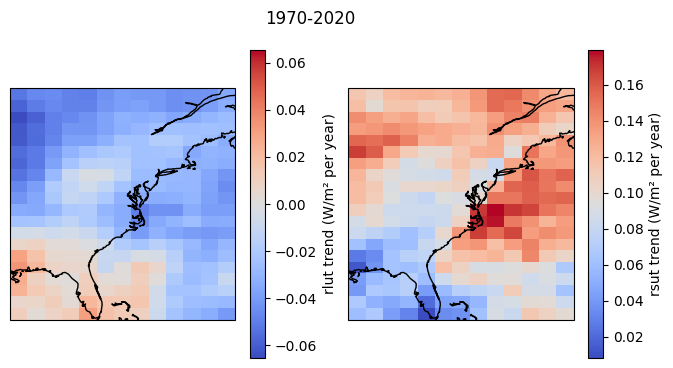

In [54]:
vars = ['rlut', 'rsut'] # SW and LW outgoing
source_id = 'ACCESS-CM2'
experiment_id = 'hist-aer'
fig, axs = plt.subplots(1, 2, figsize=(8, 4), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
for ax, var in zip(axs, vars):
    if var == 'rsut':
        dataset = datasets[source_id][experiment_id][var].rsut
    elif var == 'rlut':
        dataset = datasets[source_id][experiment_id][var].rlut
    dataset_annual = dataset.resample(time="YS").mean()
    #dataset_annual = dataset # for monthly

    slope_vals = np.zeros((20,13))

    ystart, yend = 1970, 2020
    istart, iend = ystart-1950, yend-1950
    #istart, iend = 12*istart, 12*iend # for monthly
    for i, lat in enumerate(dataset_annual.lat):
        for j, lon in enumerate(dataset_annual.lon):
            dataset_annual_latlon = dataset_annual.sel(lat=lat, lon=lon)
            # linear model, 1970 onward
            model = linregress(np.arange(dataset_annual_latlon[istart:iend+1].size), dataset_annual_latlon[istart:iend+1].data)
            slope = model.slope # W/m^2 per year
            slope_vals[i,j] = slope

    new_ds = dataset_annual.to_dataset().assign(trend=(('lat', 'lon'), slope_vals))

    plot_subset = new_ds['trend']

    
    plot_subset.plot.pcolormesh(
        ax=ax,
        x='lon', y='lat',
        transform=ccrs.PlateCarree(),   # tells cartopy the data's CRS (0-360 is fine here)
        cmap='coolwarm',
        cbar_kwargs={'label': f'{var} trend (W/m² per year)'},
        #vmin=-1, vmax=1
    )
    ax.coastlines()
plt.suptitle(f'{ystart}-{yend}')
#plt.savefig(f'lw-sw-trend-{ystart}-{yend}.pdf', format='pdf')

In [85]:
def plotBiasTOAFluxes(source_id):
    """Plot Bias in outgoing LW and SW TOA fluxes between 2010s and 1960s"""
    vars = ['rlut', 'rsut'] # SW and LW outgoing
    experiment_id = 'hist-aer'
    fig, axs = plt.subplots(1, 2, figsize=(8, 4), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
    for ax, var in zip(axs, vars):
        if var == 'rsut':
            dataset = datasets[source_id][experiment_id][var].rsut
        elif var == 'rlut':
            dataset = datasets[source_id][experiment_id][var].rlut
        
        # 1960-1969 mean for each grid cell (just before CAA)
        var60_mean = dataset.sel(time=slice("1960-01-01", "1969-12-01")).mean(axis=0)
        # 2010-2020 mean for each grid cell
        var10_mean = dataset.sel(time=slice("2010-01-01", "2020-12-01")).mean(axis=0)

        # compute bias between 2010s and 1960s 
        var_bias = var10_mean - var60_mean
        
        var_bias.plot.pcolormesh(
            ax=ax,
            x='lon', y='lat',
            transform=ccrs.PlateCarree(),   # tells cartopy the data's CRS (0-360 is fine here)
            cmap='coolwarm',
            cbar_kwargs={'label': f'{var} bias'},
            vmin=-10, vmax=10
        )
        #ax.coastlines()
        #ax.add_feature(cfeature.BORDERS)
        ax.add_feature(cfeature.STATES)
    #plt.suptitle(f'{ystart}-{yend}')

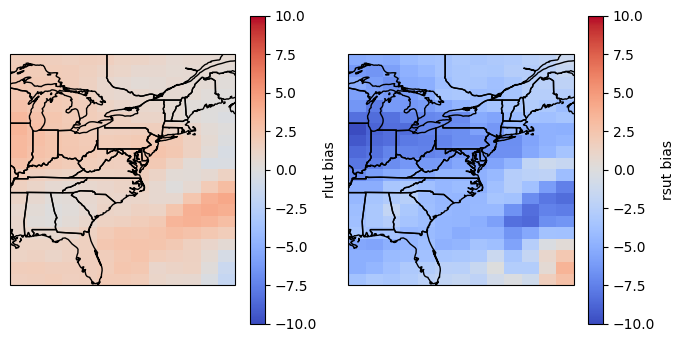

In [86]:
plotBiasTOAFluxes(source_id = 'ACCESS-CM2')

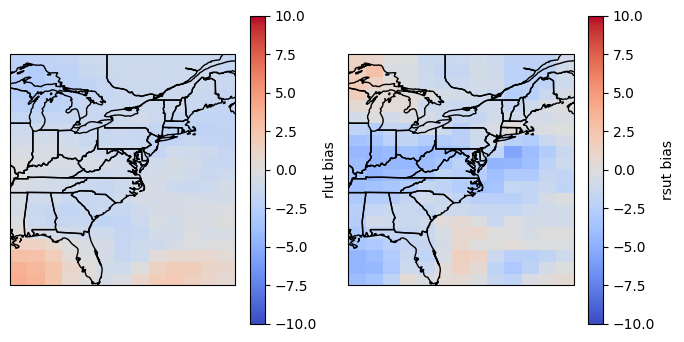

In [87]:
plotBiasTOAFluxes(source_id = 'HadGEM3-GC31-LL')

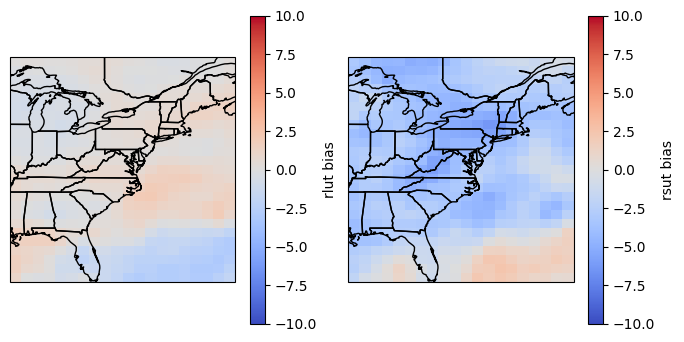

In [88]:
plotBiasTOAFluxes(source_id = 'GFDL-ESM4')

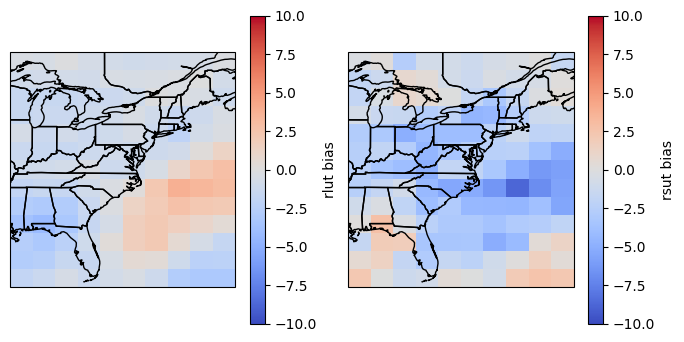

In [89]:
plotBiasTOAFluxes(source_id = 'GISS-E2-1-G')

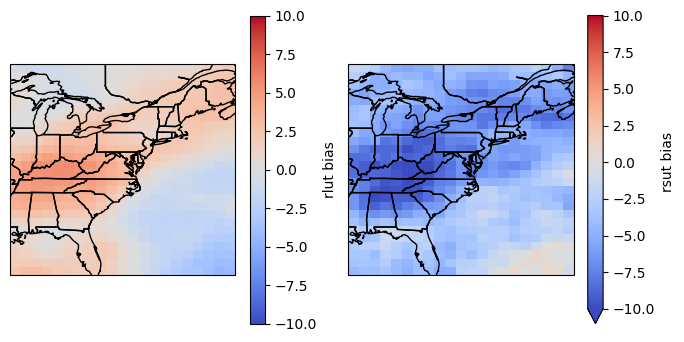

In [90]:
plotBiasTOAFluxes(source_id = 'CESM2')

In [86]:
def plotBiasTOAFluxesAllModels():
    """Plot Bias in outgoing LW and SW TOA fluxes between 2010s and 1960s"""

    fig, axs = plt.subplots(len(datasets.keys()), 2, figsize=(5, 8), 
                         subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
    plt.subplots_adjust(left=0.27, right=1, wspace=0.01, hspace=0.04, bottom=0.12, top=.95)

    for i, source_id in enumerate(datasets.keys()):
        vars = ['rlut', 'rsut']  # SW and LW outgoing
        experiment_id = 'hist-aer'
        model_axs = axs[i, :]
        for ax, var in zip(model_axs, vars):
            if var == 'rsut':
                dataset = datasets[source_id][experiment_id][var].rsut
            elif var == 'rlut':
                dataset = datasets[source_id][experiment_id][var].rlut
            
            # 1960-1969 mean for each grid cell (just before CAA)
            var60_mean = dataset.sel(time=slice("1960-01-01", "1969-12-01")).mean(axis=0)
            # 2010-2020 mean for each grid cell
            var10_mean = dataset.sel(time=slice("2010-01-01", "2020-12-01")).mean(axis=0)

            # compute bias between 2010s and 1960s 
            var_bias = var10_mean - var60_mean
            
            im = var_bias.plot.pcolormesh(
                ax=ax,
                x='lon', y='lat',
                transform=ccrs.PlateCarree(),
                cmap='coolwarm',
                vmin=-10, vmax=10,
                add_colorbar=False,  # disable individual colorbars
                edgecolors='none'
            )
            ax.add_feature(cfeature.STATES)
            ax.set_box_aspect(1)
        
        # Place model label to the left of the first column
        model_axs[0].text(-0.22, 0.5, source_id, 
                        transform=model_axs[0].transAxes,  va='center', ha='right', fontsize=10)

    axs[0, 0].set_title('TOA Outgoing LW', fontsize=10)
    axs[0, 1].set_title('TOA Outgoing SW', fontsize=10)

    # Add a single horizontal colorbar at the bottom
    cbar_left = model_axs[0].get_position().x0
    cbar_right= model_axs[1].get_position().x1

    cbar_ax = fig.add_axes([cbar_left, 0.07, cbar_right-cbar_left, 0.02])  # [left, bottom, width, height]
    fig.colorbar(im, cax=cbar_ax, orientation='horizontal', label='Bias, 2010s - 1960s (W/m$^2$)')
    plt.savefig('toa-damip-eastern-us-bias.png', format='png')

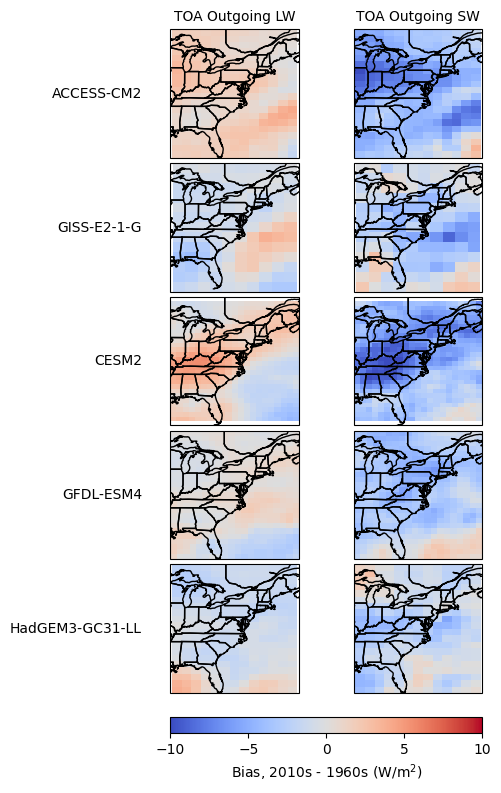

In [87]:
plotBiasTOAFluxesAllModels()